In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

customers = pd.read_csv("../data/clean/customers_clean.csv")
accounts = pd.read_csv("../data/clean/accounts_clean.csv")
loans = pd.read_csv("../data/clean/loans_clean.csv")
transactions = pd.read_csv("../data/clean/transactions_clean.csv")
branches = pd.read_csv("../data/clean/branches_clean.csv")

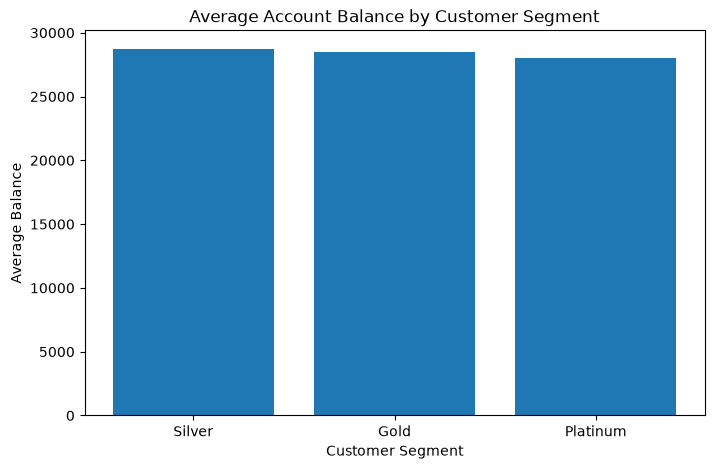

In [6]:
customer_accounts = customers.merge(accounts,on="customer_id",how="inner")

segment_balance = (
    customer_accounts
    .groupby("customer_segment")["balance"]
    .mean()
    .sort_values(ascending=False))

plt.figure(figsize=(8,5))
plt.bar(segment_balance.index, segment_balance.values)

plt.title("Average Account Balance by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Balance")

plt.show()

Slight Reverse Trend: Silver has the highest average balance, followed by Gold, and then Platinum.

Nearly Identical Values: All three tiers are extremely close, hovering around $28,000 to $28,800.

Main Takeaway: Account balance alone does not drive higher tier placement, as higher tiers (Gold/Platinum) don't carry higher average balances here.

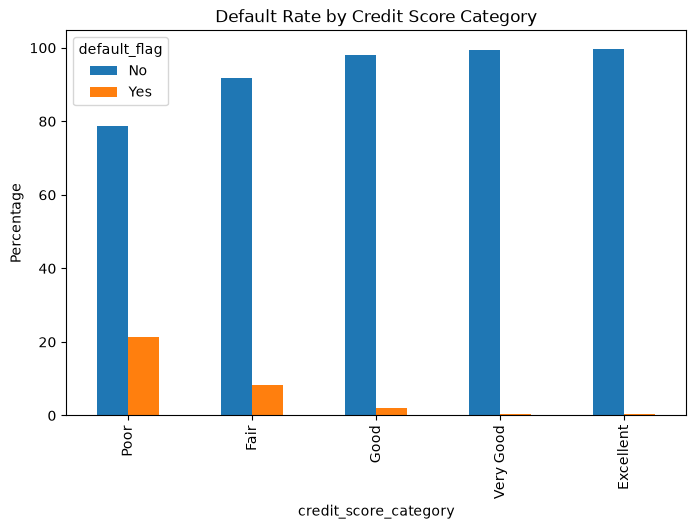

In [9]:
loans["credit_score_category"] = pd.cut(
    loans["credit_score"],
    bins=[300,580,670,740,800,850],
    labels=["Poor","Fair","Good","Very Good","Excellent"],
    include_lowest=True
)

default_rate = pd.crosstab(
    loans["credit_score_category"],
    loans["default_flag"],
    normalize="index"
) * 100

default_rate.plot(kind="bar", figsize=(8,5))

plt.title("Default Rate by Credit Score Category")
plt.ylabel("Percentage")

plt.show()

Inverse Relationship: As credit scores improve (from Poor to Excellent), the default rate (Yes, in orange) drops sharply.

Highest Risk in Poor Credit: Customers in the Poor category have the highest default rate by far at ~21%.

Minimal Risk in Top Tiers: The default rate drops to under 2% for Good credit and becomes virtually 0% for Very Good and Excellent categories.

Main Takeaway: Higher credit scores are a very reliable predictor of lower loan default risk.

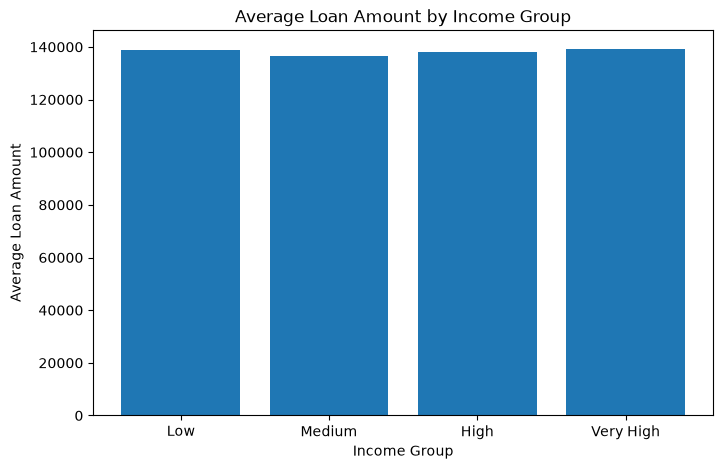

In [12]:
customers["income_group"] = pd.qcut(
    customers["annual_income"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

customer_loans = customers.merge(loans,on="customer_id")
income_loan = (customer_loans.groupby("income_group")["loan_amount"].mean())

plt.figure(figsize=(8,5))
plt.bar(income_loan.index.astype(str), income_loan.values)

plt.title("Average Loan Amount by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Loan Amount")

plt.show()

Uniform Across Groups: The average loan amount is virtually identical across all income brackets (Low, Medium, High, and Very High).

Consistent Threshold: Every income group averages around $137,000 to $139,000.

Main Takeaway: Income level does not significantly influence the average loan amount requested or approved in this dataset.

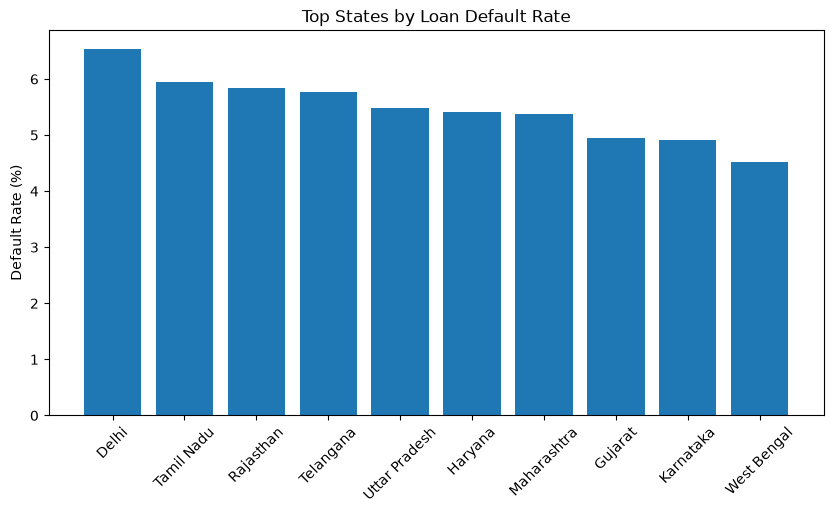

In [13]:
state_default = (
    customer_loans
    .groupby("state")["default_flag"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(state_default.index, state_default.values)

plt.xticks(rotation=45)

plt.title("Top States by Loan Default Rate")
plt.ylabel("Default Rate (%)")

plt.show()

Highest Risk State: Delhi tops the list with the highest loan default rate at around 6.5%.

Moderate Range: Most of the top 10 states (from Tamil Nadu down to Karnataka) hover closely between 5% and 6%.

Lowest Among Top 10: West Bengal has the lowest default rate on this list at around 4.5%.

Main Takeaway: Regional default rates show only minor variance overall, spanning a narrow band of roughly 4.5% to 6.5% across these top 10 states.

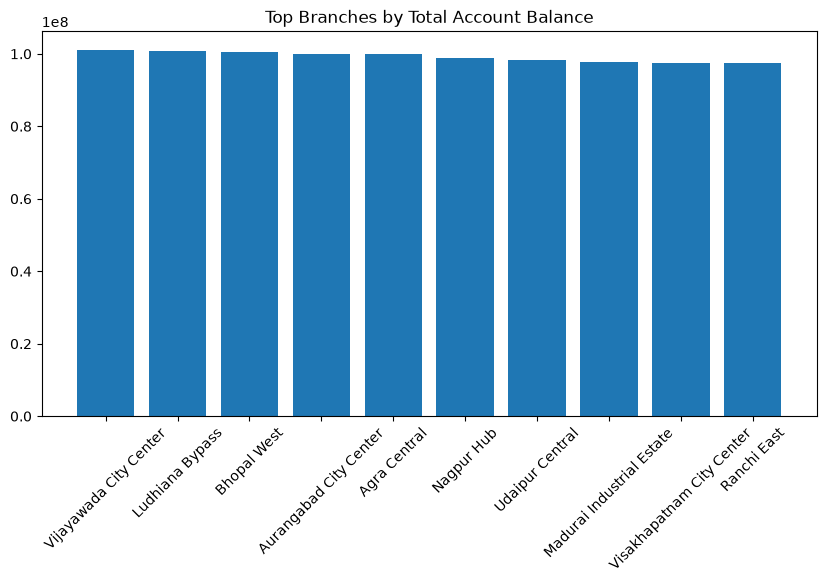

In [14]:
branch_accounts = accounts.merge(branches,on="branch_id")

branch_balance = (
    branch_accounts
    .groupby("branch_name")["balance"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(branch_balance.index, branch_balance.values)

plt.xticks(rotation=45)

plt.title("Top Branches by Total Account Balance")

plt.show()

Top Performer: Vijayawada City Center leads with the highest total account balance, just above 100 million (10 Cr).

Extremely Even Distribution: All top 10 branches are practically neck-and-neck, each holding approximately 97 million to 101 million.

Lowest of the Top 10: Visakhapatnam City Center and Ranchi East are at the lower end of this group, hovering around 97 million.

Main Takeaway: Total deposit capital is distributed almost evenly across these leading branches, with less than a 4% variance from top to bottom.

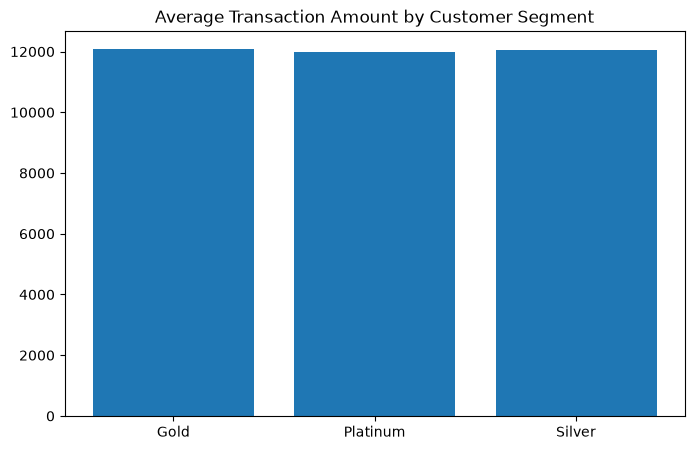

In [16]:
customer_transactions = customers.merge(transactions,on="customer_id")

segment_transaction = (customer_transactions.groupby("customer_segment")["amount"].mean())

plt.figure(figsize=(8,5))
plt.bar(segment_transaction.index, segment_transaction.values)

plt.title("Average Transaction Amount by Customer Segment")

plt.show()

Virtually Identical Averages: All three segments—Gold, Platinum, and Silver—have almost the exact same average transaction amount.

Consistent Value: Every tier hovers right around 12,000.

Main Takeaway: Customer segment tier does not impact average transaction size; customers spend similar amounts per transaction regardless of whether they are Silver, Gold, or Platinum.

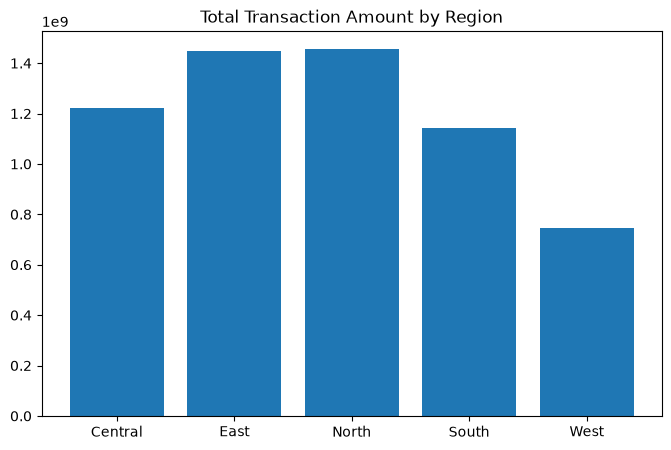

In [17]:
transaction_branch = (transactions
    .merge(accounts, on="account_id")
    .merge(branches, on="branch_id")
)

region_transaction = (transaction_branch.groupby("region")["amount"].sum())

plt.figure(figsize=(8,5))
plt.bar(region_transaction.index, region_transaction.values)

plt.title("Total Transaction Amount by Region")

plt.show()

Top Performers: North and East regions lead in overall volume, tied at the top with approximately 1.45 billion in total transactions.

Middle Performers: Central (~1.22 billion) and South (~1.14 billion) maintain strong, steady transaction totals.

Lowest Region: West trails significantly behind the rest, generating around 0.75 billion (nearly half of North or East).

Main Takeaway: Transaction values are heavily concentrated in the North and East regions, while the West region underperforms compared to all other territories.

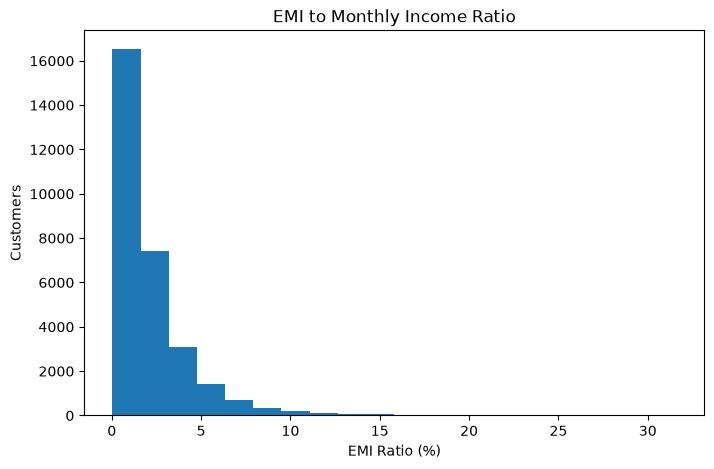

In [18]:
risk = customers.merge(loans,on="customer_id")

risk["monthly_income"] = risk["annual_income"] / 12

risk["emi_to_income_ratio"] = (risk["emi"] /risk["monthly_income"]) * 100

risk["emi_to_income_ratio"] = risk["emi_to_income_ratio"].round(2)

plt.figure(figsize=(8,5))
plt.hist(risk["emi_to_income_ratio"], bins=20)

plt.title("EMI to Monthly Income Ratio")
plt.xlabel("EMI Ratio (%)")
plt.ylabel("Customers")

plt.show()


Heavy Concentration at Low Ratios: The vast majority of customers have an EMI-to-income ratio under 3%, with the largest group falling between 0% and 1.5% (~16,500 customers).

Right-Skewed Distribution: As the EMI ratio increases, the customer count drops off sharply—very few customers allocate more than 10% of their monthly income toward EMI payments.

Low Debt Burden: Almost no customers cross the 15%–20% mark, indicating a very conservative loan portfolio with minimal debt strain relative to income.

Main Takeaway: Most borrowers maintain a safe, low EMI burden well below standard risk thresholds.